In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [265]:
awg = pd.read_excel("all-weeks-global-netflix.xlsx") 

C:\Users\my-lo\anaconda\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [331]:
mpn = pd.read_excel("most-popular-netflix.xlsx")

C:\Users\my-lo\anaconda\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [269]:
awcn = pd.read_excel("all-weeks-countries-netflix.xlsx")

C:\Users\my-lo\anaconda\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Differentiate between films and TV

In [271]:
def classify_type(cat):
    if "Films" in cat:
        return "Film"
    else:
        return "Series"
        
awg["type"] = awg["category"].apply(classify_type)

This shows how many weeks they have stayed in the Top 10

In [274]:
title_lifetime = awg.groupby(["show_title", "type"])["week"].nunique().reset_index()
title_lifetime.columns = ["show_title", "type", "weeks_in_top_10"]

Median & mean number of weeks in each type

In [277]:
median_weeks = title_lifetime.groupby("type")["weeks_in_top_10"].median().reset_index()

In [279]:
mean_weeks = title_lifetime.groupby("type")["weeks_in_top_10"].mean().reset_index()


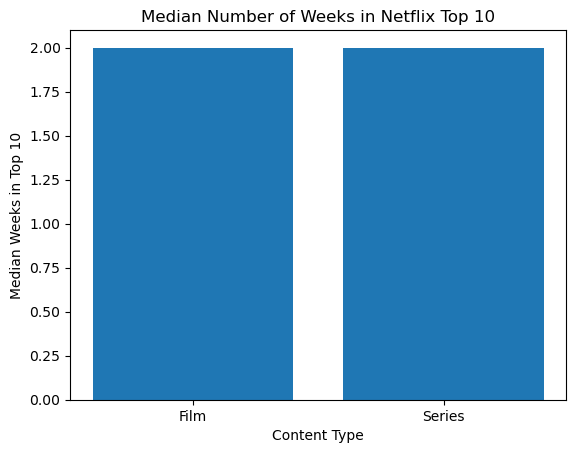

In [281]:
plt.bar(data=median_weeks, x="type", height="weeks_in_top_10")
plt.title("Median Number of Weeks in Netflix Top 10")
plt.xlabel("Content Type")
plt.ylabel("Median Weeks in Top 10")
plt.show()

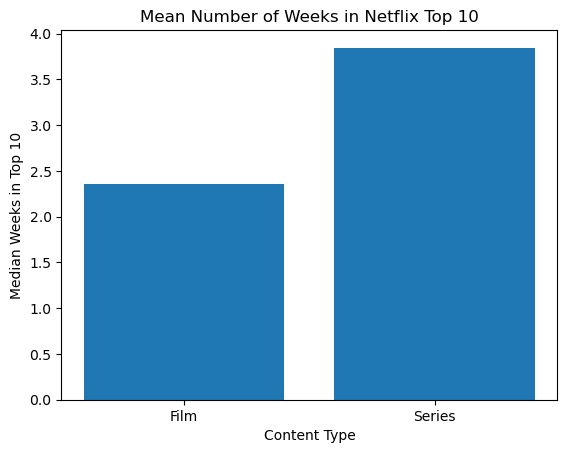

In [283]:
plt.bar(data=mean_weeks, x="type", height="weeks_in_top_10")
plt.title("Mean Number of Weeks in Netflix Top 10")
plt.xlabel("Content Type")
plt.ylabel("Median Weeks in Top 10")
plt.show()

In [333]:
category_avg = mpn.groupby("category").agg({
    "hours_viewed_first_91_days": "mean",
    "views_first_91_days": "mean"
}).reset_index()

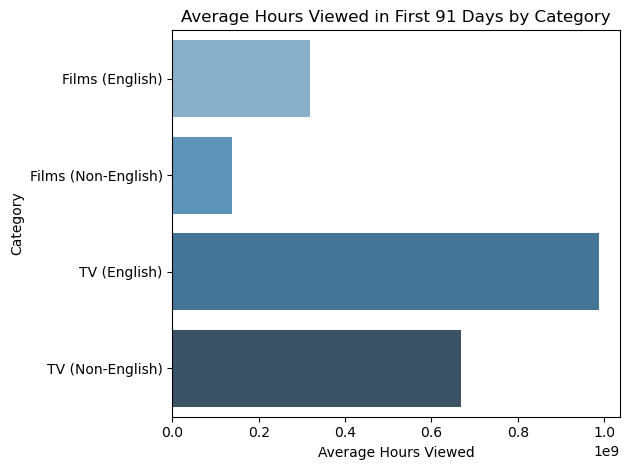

In [335]:
sns.barplot(data=category_avg, x="hours_viewed_first_91_days", y="category", palette="Blues_d")
plt.title("Average Hours Viewed in First 91 Days by Category")
plt.xlabel("Average Hours Viewed")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

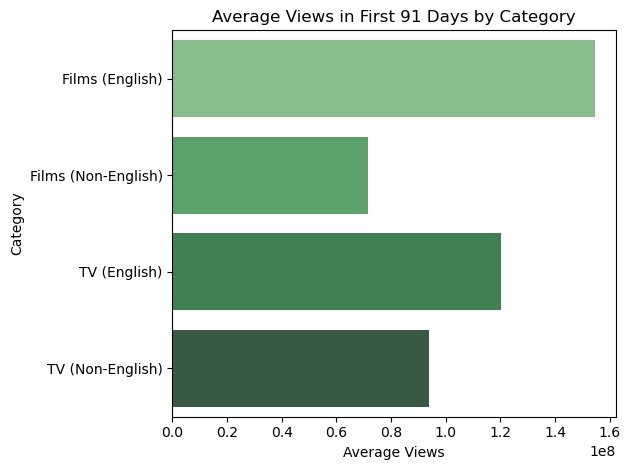

In [337]:
sns.barplot(data=category_avg, x="views_first_91_days", y="category", palette="Greens_d")
plt.title("Average Views in First 91 Days by Category")
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [285]:
awg["week"] = pd.to_datetime(df["week"])

In [287]:
weekly_hours_by_type = awg.groupby(["week", "type"])["weekly_hours_viewed"].sum().reset_index()


C:\Users\my-lo\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\my-lo\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


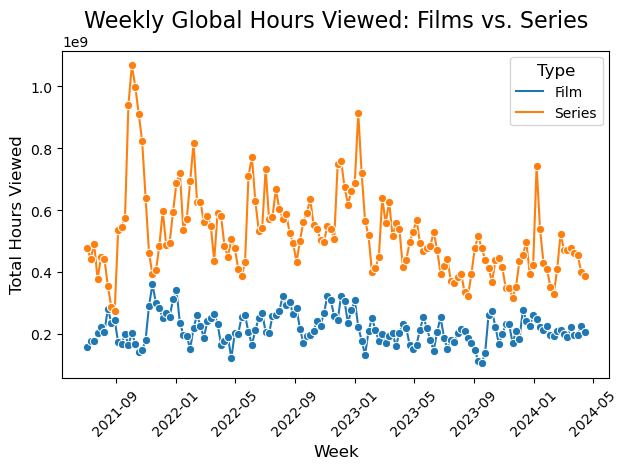

In [289]:
sns.lineplot(data=weekly_hours_by_type, x="week", y="weekly_hours_viewed", hue="type", marker="o")
plt.title("Weekly Global Hours Viewed: Films vs. Series", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Total Hours Viewed", fontsize=12)
plt.legend(title="Type", title_fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I would like to combine all datasets into one dataframe to analyze further. I first started by cleaning the titles. 

In [291]:
mpn.columns = [col.strip().lower().replace(" ", "_") for col in mpn.columns]
awg.columns = [col.strip().lower().replace(" ", "_") for col in awg.columns]
awcn.columns = [col.strip().lower().replace(" ", "_") for col in awcn.columns]

In [293]:
mpn["cleaned_title"] = mpn["show_title"].str.strip().str.lower()
awg["cleaned_title"] = awg["show_title"].str.strip().str.lower()
awcn["cleaned_title"] = awcn["show_title"].str.strip().str.lower()

I ultimately want to know how many times they have been in top 10, I have grouped them by the week. 

In [295]:
weeks_count = (awcn[awcn["cleaned_title"].isin(awg["cleaned_title"])].groupby("cleaned_title")["week"].nunique().reset_index(name="weeks_in_top_10"))

After, I would like to merge all three dataset, preserving their categories as well. 

In [297]:
combined_df = weeks_count.merge(mpn, on="cleaned_title", how="left")


In [301]:
awcn = awcn.loc[:, ~awcn.columns.duplicated()]

In [303]:
awcn_subset = awcn[["cleaned_title", "category"]].drop_duplicates(subset=["cleaned_title"])
awcn_subset = awcn_subset.rename(columns={"category": "category_awcn"})
combined_df = combined_df.merge(awcn_subset, on="cleaned_title", how="left")
combined_df["category_combined"] = combined_df["category"].fillna(combined_df["category_awcn"])

In [305]:
combined_sorted_df = combined_df.assign(has_category=combined_df["category_combined"].notna()).sort_values(by=["has_category", "weeks_in_top_10"], ascending=[False, False])

Dropping unnecessary columns

In [309]:
combined_sorted_df = combined_sorted_df.drop(['category', 'rank','hours_viewed_first_91_days','runtime','views_first_91_days','category_awcn'], axis=1)

In [311]:
combined_sorted_df.head(25)

,cleaned_title,weeks_in_top_10,show_title,season_title,category_combined,has_category
989,money heist,115,Money Heist,Money Heist: Part 4,TV (Non-English),True
990,money heist,115,Money Heist,Money Heist: Part 5,TV (Non-English),True
991,money heist,115,Money Heist,Money Heist: Part 3,TV (Non-English),True
1494,the good doctor,106,NaN,NaN,TV,True
1103,"pablo escobar, el patrón del mal",102,NaN,NaN,TV,True
1113,pasión de gavilanes,102,NaN,NaN,TV,True
1416,the blacklist,99,NaN,NaN,TV,True
290,chiquititas,93,NaN,NaN,TV,True
1115,paw patrol,88,NaN,NaN,TV,True
318,cocomelon,84,NaN,NaN,TV,True


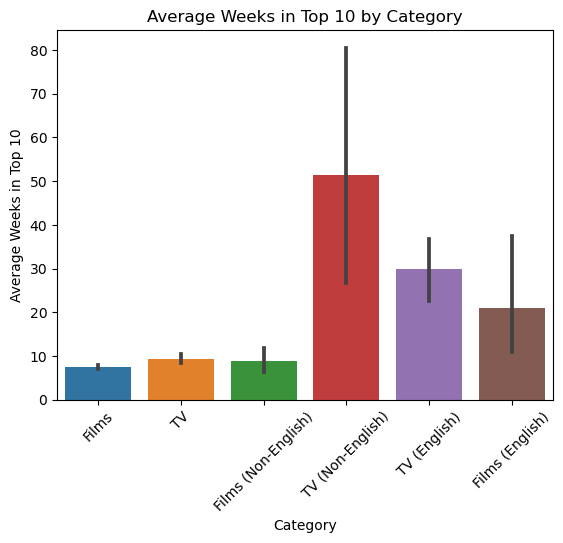

In [313]:
sns.barplot(data=combined_df, x="category_combined", y="weeks_in_top_10", estimator='mean')
plt.title("Average Weeks in Top 10 by Category")
plt.ylabel("Average Weeks in Top 10")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.show()

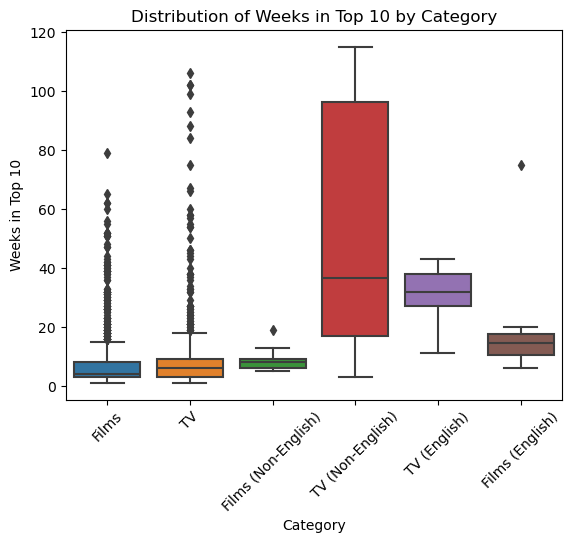

In [315]:
sns.boxplot(data=combined_df, x="category_combined", y="weeks_in_top_10")
plt.title("Distribution of Weeks in Top 10 by Category")
plt.xlabel("Category")
plt.ylabel("Weeks in Top 10")
plt.xticks(rotation=45)
plt.show()